In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import welch
import jax
import jax.numpy as jnp
from ripple.waveforms import TaylorF2
from ripplegw import ms_to_Mc_eta
from pathlib import Path
import h5py

In [31]:
filepath = Path("/n/holystore01/LABS/iaifi_lab/Lab/creissel/SparseBank/test_ripple/test/sig_combined_test_0.h5")

sample_rate = 512    # Hz
f_low       = 20.0   # Hz — low-frequency cutoff
f_high      = 256.0  # Hz — Nyquist (= SAMPLE_RATE / 2)
f_ref       = 20.0   # Hz — reference frequency for waveform
duration    = 64.0   # s  — stored window length
ifos        = ['H1', 'L1']

EVENT_IDX = 1

with h5py.File(filepath, "r") as f:
    strain_all = f["injected_data"][:]          # (N, 2, n_time)
    params = {k: f[k][:] for k in f.keys() if k != "injected_data"}

strain_H1 = strain_all[EVENT_IDX, 0, :]   # H1 whitened strain
strain_L1 = strain_all[EVENT_IDX, 1, :]   # L1 whitened strain

m1_true   = float(params["mass_1"][EVENT_IDX])
m2_true   = float(params["mass_2"][EVENT_IDX])
chi1_true = float(params["chi1"][EVENT_IDX])
chi2_true = float(params["chi2"][EVENT_IDX])
dist_true = float(params["distance"][EVENT_IDX])
phic_true = float(params["phic"][EVENT_IDX])
psi_true  = float(params["psi"][EVENT_IDX])
inclination_true = float(params["inclination"][EVENT_IDX])
snr_true  = float(params["snr"][EVENT_IDX])
Mc_true, eta_true = ms_to_Mc_eta(jnp.array([m1_true, m2_true]))

print(f"Event index   : {EVENT_IDX}")
print(f"m1            : {m1_true:.3f} M_sun")
print(f"m2            : {m2_true:.3f} M_sun")
print(f"Chirp mass    : {float(Mc_true):.4f} M_sun")
print(f"chi1, chi2    : {chi1_true:.3f}, {chi2_true:.3f}")
print(f"Distance      : {dist_true:.1f} Mpc")
print(f"Inclination   : {inclination_true:.3f}")
print(f"Phic          : {phic_true:.1f}")
print(f"Psi           : {psi_true:.1f}")
print(f"Network SNR   : {snr_true:.2f}")

Event index   : 1
m1            : 2.060 M_sun
m2            : 1.160 M_sun
Chirp mass    : 1.3348 M_sun
chi1, chi2    : 0.000, 0.000
Distance      : 890.7 Mpc
Inclination   : 0.708
Phic          : 0.0
Psi           : 0.5
Network SNR   : 8.93


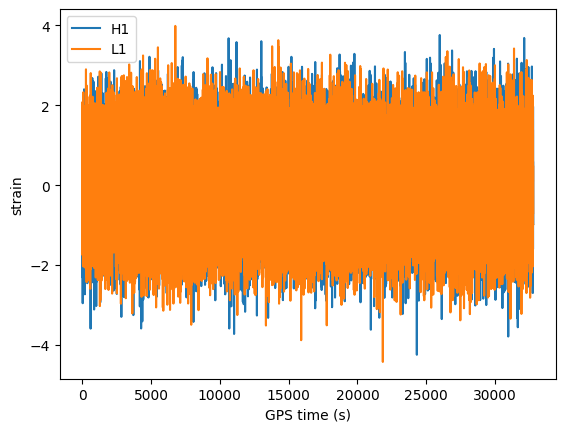

In [32]:
data_td_dict = {'H1': strain_H1, 'L1': strain_L1}

for ifo, data in data_td_dict.items():
    plt.plot(data, label=ifo)
plt.xlabel("GPS time (s)")
plt.ylabel("strain")
plt.legend()

In [33]:
n = int(sample_rate * duration)
delta_t = 1/sample_rate
freq = np.fft.rfftfreq(n, delta_t)

In [34]:
params.keys()

dict_keys(['chi1', 'chi2', 'chirp_mass', 'dec', 'distance', 'inclination', 'mass_1', 'mass_2', 'mass_ratio', 'phi', 'phic', 'psd', 'psi', 's1z', 's2z', 'snr'])

In [35]:
f = freq

m1_msun = m1_true
m2_msun = m2_true
chi1 = 0.0
chi2 = 0.0
tc = 63.0  # Time of coalescence in seconds
phic = phic_true
dist_mpc = dist_true  # Distance to source in Mpc
inclination = inclination_true  # Inclination Angle
polarization_angle = 0  # Polarization angle

f_ref = 20.0

Mc, eta = ms_to_Mc_eta(jnp.array([m1_msun, m2_msun]))

# params = jnp.array([30, 0.249, 0.1,0.1, 400, 0.0, 0.0, 0.1, 0.0])
theta = jnp.array(
    [Mc, eta, chi1, chi2, 0.0, 0.0, dist_mpc, tc, phic, inclination]
)

# call ripple
hp_ripple, hc_ripple = TaylorF2.gen_TaylorF2_hphc(f[1:], theta, f_ref)

# restore zero-frequency component
hp_ripple = np.insert(hp_ripple, 0, 0)
hc_ripple = np.insert(hc_ripple, 0, 0)

hp_ripple[f < f_low] = 0
hc_ripple[f < f_low] = 0

In [36]:
hp_ripple

array([0.0000000e+00+0.0000000e+00j, 0.0000000e+00+0.0000000e+00j,
       0.0000000e+00+0.0000000e+00j, ..., 1.3615133e-25-5.7817457e-27j,
       1.3586392e-25+1.0438884e-26j, 1.3385403e-25+2.5464316e-26j],
      shape=(16385,), dtype=complex64)

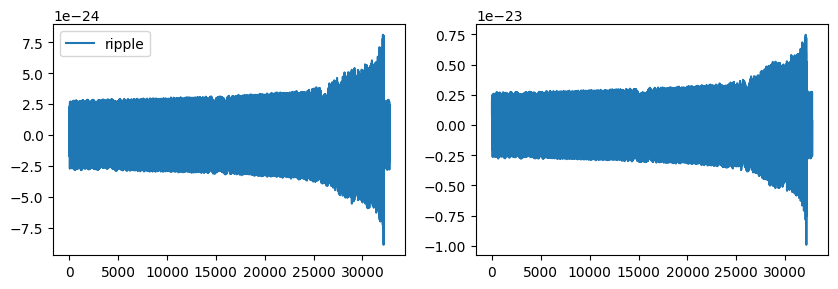

In [37]:
hp_ripple_td = np.fft.irfft(hp_ripple) / delta_t
hc_ripple_td = np.fft.irfft(hc_ripple) / delta_t

fig, axs = plt.subplots(1, 2, figsize=(10, 3))

axs[0].plot(hp_ripple_td, label="ripple")
#axs[0].set_xlim([sample_rate*60, sample_rate*duration])
axs[1].plot(hc_ripple_td)
#axs[1].set_xlim([sample_rate*60, sample_rate*duration])
axs[0].legend()

In [38]:
mask = (freq >= f_low) & (freq <= f_high)
def whiten(h_rfft, psd, freq):
    h_whitened = h_rfft / np.sqrt(psd)
    h_whitened = h_whitened[mask]
    return h_whitened

# Whiten template
h_whiten = {'H1': whiten(hp_ripple, params['psd'][EVENT_IDX, 0, :], freq),
            'L1': whiten(hp_ripple, params['psd'][EVENT_IDX, 1, :], freq)
           }
# Check whitened amplitude
print(f"Max |h_w(f)|   : {np.abs(h_whiten['H1']).max():.3e}")

Max |h_w(f)|   : 2.391e-01


In [39]:
h_whiten['H1'].shape

(15105,)

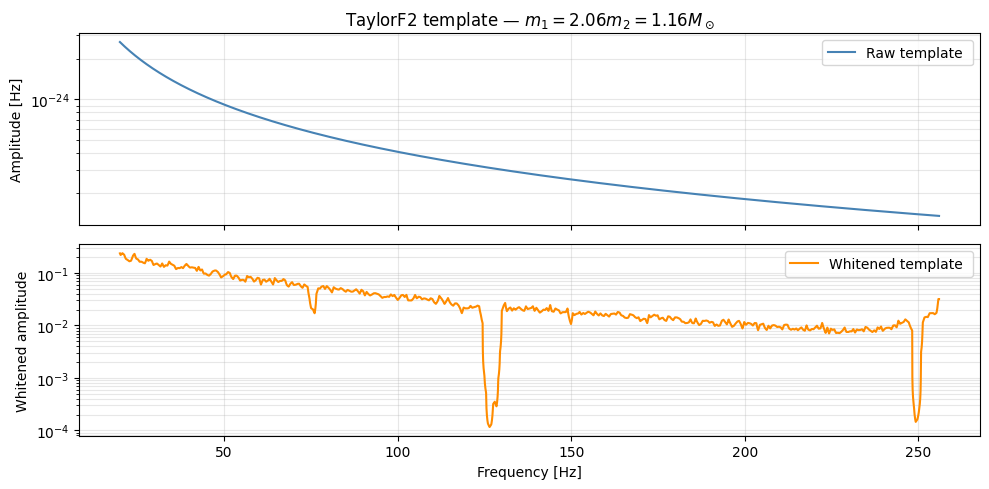

In [40]:
fig, axes = plt.subplots(2, 1, figsize=(10, 5), sharex=True)
mask = (freq >= f_low) & (freq <= f_high)

axes[0].semilogy(freq[mask], np.abs(hp_ripple[mask]),
                 color='steelblue', label='Raw template ')
axes[0].set_ylabel('Amplitude [Hz]')
axes[0].legend()
axes[0].grid(True, which='both', alpha=0.3)
axes[0].set_title(
    f'TaylorF2 template — $m_1={m1_true:.2f}m_2={m2_true:.2f}M_\odot$'
)

axes[1].semilogy(freq[mask], np.abs(h_whiten['H1']),
                 color='darkorange', label='Whitened template ')
axes[1].set_xlabel('Frequency [Hz]')
axes[1].set_ylabel('Whitened amplitude')
axes[1].legend()
axes[1].grid(True, which='both', alpha=0.3)

plt.tight_layout()
plt.show()

## Matched Filter

In [41]:
def matched_filter_whitened(strain, h_w, df, N):
    """
    Matched filter for pre-whitened data with a whitened template.

    Parameters
    ----------
    strain : 1-D real array, length N
        Pre-whitened time-domain strain (zero-padded to length N).
    h_w : complex array, length N//2+1
        Whitened frequency-domain template on the rfft grid.
    df : float
        Frequency resolution [Hz].
    N : int
        FFT length.

    Returns
    -------
    snr_t   : real array, shape (N,)  — SNR time series |z(t)| / sigma_h
    sigma_h : float                   — template normalisation
    """
    # FFT of the whitened data
    s_f = np.fft.rfft(strain) / sample_rate
    s_f = s_f[mask]

    # Template norm: sigma_h^2 = 4 * sum(|h_w|^2) * df
    sigma_h = np.sqrt(4.0 * np.sum(np.abs(h_w)**2).real * df)

    # Complex SNR in time domain via IFFT
    z_f = 4.0 * np.conj(h_w) * s_f
    z_t = np.fft.irfft(z_f, n=N) * (N * df)

    return np.abs(z_t) / sigma_h, sigma_h


def run_matched_filter(ifo, data, h_whiten):
    
    snr_t, sigma_h = matched_filter_whitened(data[ifo], h_whiten[ifo], 1.0/64.0, int(duration*sample_rate))
    # Peak within the full time series
    peak_idx  = np.argmax(snr_t)
    peak_snr  = snr_t[peak_idx]
    t_axis = np.arange(int(duration*sample_rate)) / sample_rate
    peak_time = t_axis[peak_idx]

    print(f"Peak SNR       : {peak_snr:.2f}")
    print(f"Peak time      : {peak_time:.3f} s")
    return snr_t, peak_snr, peak_time

snr_H1, peak_snr_H1, peak_time_H1 = run_matched_filter('H1', data_td_dict, h_whiten)
snr_L1 = run_matched_filter('L1', data_td_dict, h_whiten)

Peak SNR       : 0.56
Peak time      : 0.020 s
Peak SNR       : 0.91
Peak time      : 0.010 s


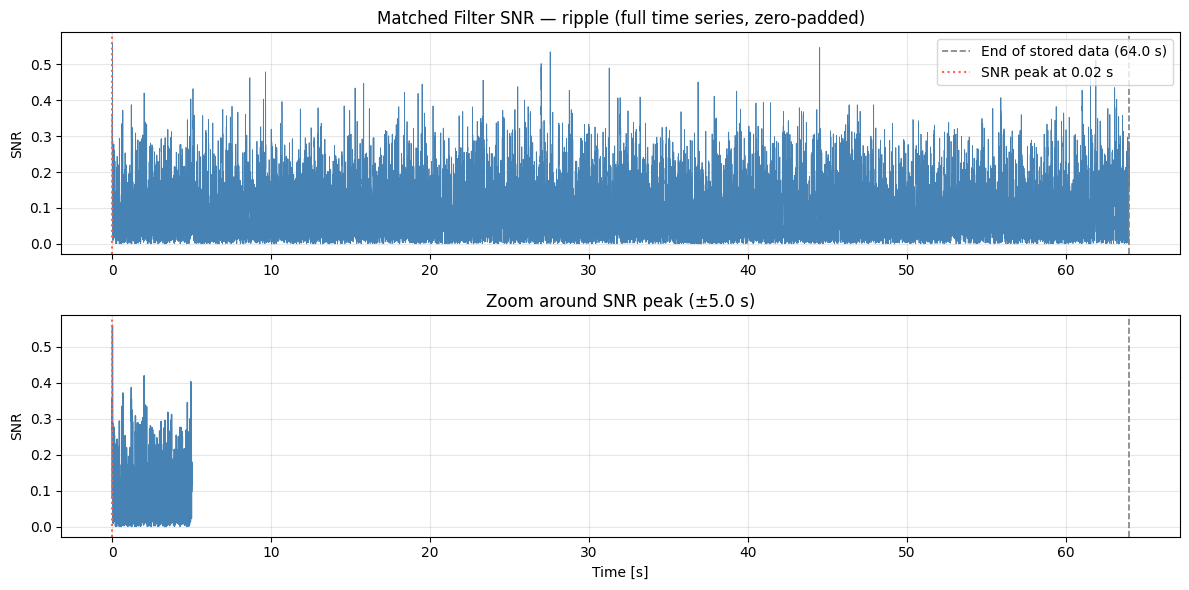

In [42]:
fig, axes = plt.subplots(2, 1, figsize=(12, 6))
t_axis = np.arange(int(duration*sample_rate)) / sample_rate
# Top: full SNR time series
axes[0].plot(t_axis, snr_H1, lw=0.6, color='steelblue')
axes[0].axvline(duration, color='grey', ls='--', lw=1.2, label=f'End of stored data ({duration} s)')
axes[0].axvline(peak_time_H1, color='tomato', ls=':', lw=1.5, label=f'SNR peak at {peak_time_H1:.2f} s')
axes[0].set_ylabel('SNR')
axes[0].set_title('Matched Filter SNR — ripple (full time series, zero-padded)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Bottom: zoom around the peak
zoom_win = 5.0
t_lo = max(0, peak_time_H1 - zoom_win)
t_hi = min(duration*sample_rate, peak_time_H1 + zoom_win)
mask_zoom = (t_axis >= t_lo) & (t_axis <= t_hi)
axes[1].plot(t_axis[mask_zoom], snr_H1[mask_zoom], lw=1.0, color='steelblue')
axes[1].axvline(duration, color='grey', ls='--', lw=1.2)
axes[1].axvline(peak_time_H1, color='tomato', ls=':', lw=1.5)
axes[1].set_xlabel('Time [s]')
axes[1].set_ylabel('SNR')
axes[1].set_title(f'Zoom around SNR peak (±{zoom_win} s)')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Make everything differentiable

In [ ]:
# example for H1

psd_jax    = jnp.array(params['psd'][EVENT_IDX, 0, :])
data_f_jax = jnp.array(np.fft.rfft(data_td_dict['H1']) / sample_rate)
df_jax     = jnp.float64(1.0/64.0)
band_jax   = jnp.array(mask)
f_grid_jax = jnp.array(freq[mask])

@jax.jit
def snr_scalar(theta, data_f_in, psd_in, f_grid_in, f_ref_in,
               n_rfft, df_in, band_in):
    """Differentiable scalar |SNR| at fixed tc using the whitened inner product."""
    hp, _ = TaylorF2.gen_TaylorF2_hphc(f_grid_in, theta, f_ref_in)

    # Whiten
    safe = jnp.where(band_in & jnp.isfinite(psd_in) & (psd_in > 0), psd_in, jnp.inf)
    h_w  = jnp.where(band_in, h_pad / jnp.sqrt(safe), 0.0 + 0.0j)

    # Inner product  (flat PSD, evaluate at tc=0)
    integrand = jnp.conj(h_w) * data_f_in
    hs        = 4.0 * jnp.abs(jnp.sum(integrand)) * df_in
    sigma_h   = jnp.sqrt(4.0 * jnp.sum(jnp.abs(h_w)**2).real * df_in)

    return hs / sigma_h


snr_val = snr_scalar(theta, data_f_jax, psd_jax, f_grid_jax,
                     float(f_ref), len(freq), df_jax, band_jax)
print(f"Differentiable |SNR| at true params : {float(jnp.abs(snr_val)):.3f}")

grad_fn = jax.grad(lambda th: jnp.abs(
    snr_scalar(th, data_f_jax, psd_jax, f_grid_jax,
               F_REF, idx_low, len(f_rfft), df_jax, band_jax)
))

g = grad_fn(theta_true)
param_names = ['Mc', 'eta', 'chi1', 'chi2', 'dist', 'tc', 'phic', 'lam1', 'lam2']
print("\nGradient of |SNR| w.r.t. source parameters:")
for name, gi in zip(param_names, g):
    print(f"  d|SNR|/d({name:6s}) = {float(gi):+.4e}")